## Rx2day - AGCD

In [1]:
import glob

import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import genextreme as gev
import numpy as np

from unseen import process_utils
from unseen import eva

In [2]:
ds = xr.open_dataset('/g/data/xv83/unseen-projects/outputs/pasha/data/rx2day_AGCD-CSIRO_1901-2024_A-AUG_pasha.nc')

In [3]:
ds

<xarray.Dataset> Size: 7kB
Dimensions:     (time: 124)
Coordinates:
  * time        (time) datetime64[ns] 992B 1901-08-31 1902-08-31 ... 2024-08-31
    event_time  (time) <U10 5kB ...
Data variables:
    pr          (time) float64 992B ...
Attributes: (12/33)
    geospatial_lat_min:        -44.525
    geospatial_lat_max:        -9.975
    geospatial_lon_min:        111.975
    geospatial_lon_max:        156.275
    time_coverage_start:       1899-12-31T09:00:00
    date_created:              2017-01-17T22:13:51.976225
    ...                        ...
    licence:                   Data Licence: The grid data files in this AGCD...
    description:               This AGCD data is a snapshot of the operationa...
    date_issued:               2025-02-06 02:46:57
    attribution:               Data should be cited as : Australian Bureau of...
    copyright:                 (C) Copyright Commonwealth of Australia 2025, ...
    history:                   Tue Sep 02 09:17:10 2025: /g/data/xv83/dbi599/...

In [4]:
df = ds.to_dataframe()
df.index = df.index.year

In [5]:
df

,pr,event_time
time,,
1901,54.521725,1900-11-19
1902,55.836872,1901-10-11
1903,119.287933,1902-10-13
1904,157.892822,1904-07-10
1905,85.077652,1905-04-03
...,...,...
2020,152.609909,2020-02-09
2021,130.785706,2021-03-20
2022,164.643692,2022-07-05


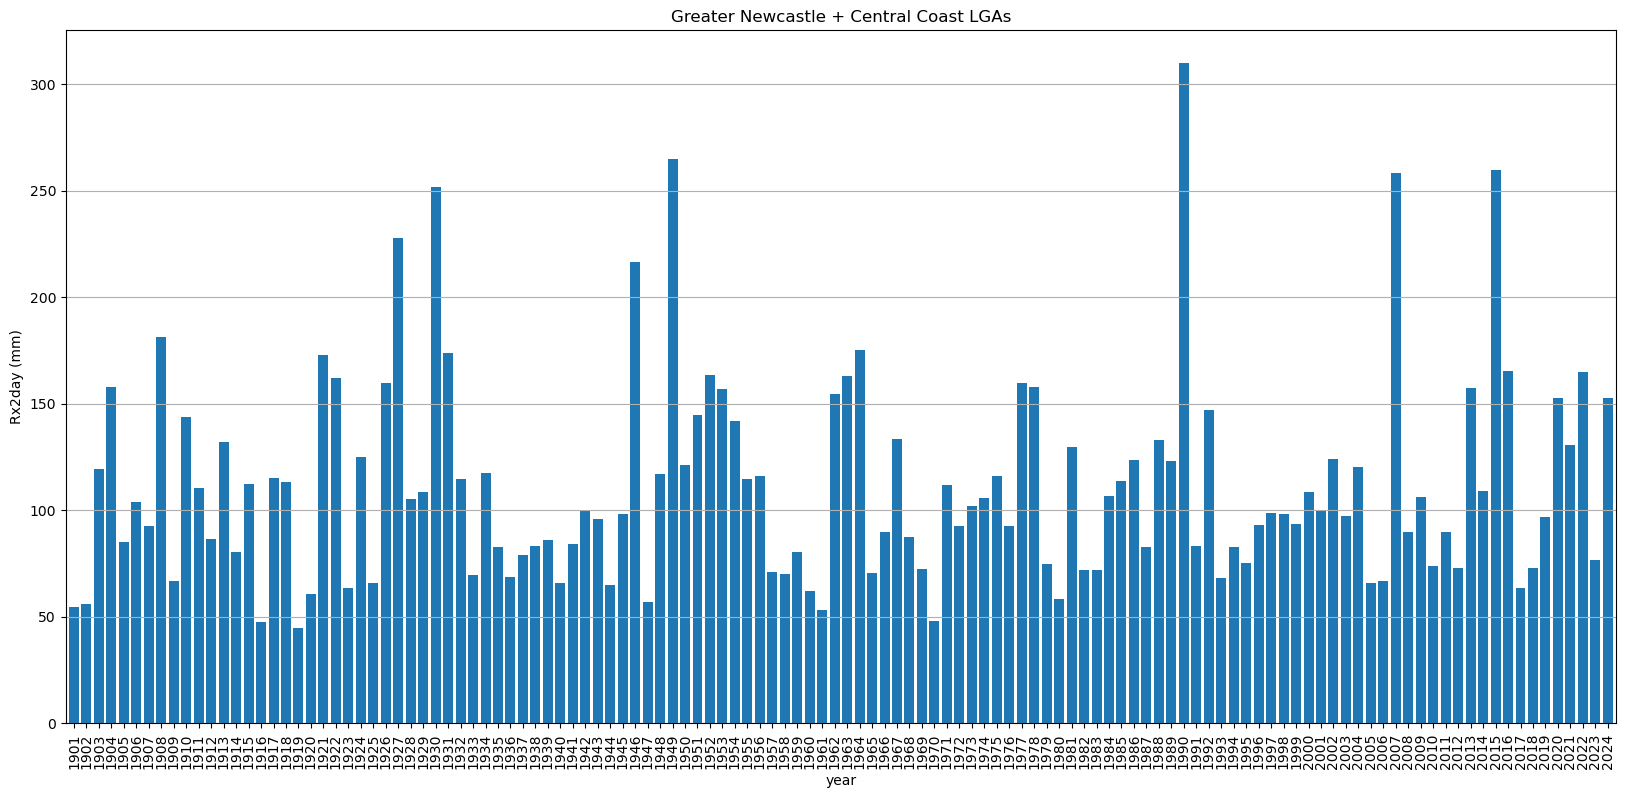

In [7]:
df['pr'].plot.bar(figsize=[20, 9], width=0.8)
plt.ylabel('Rx2day (mm)')
plt.xlabel('year')
plt.title('Greater Newcastle + Central Coast LGAs')
plt.grid(axis='y')
plt.show()

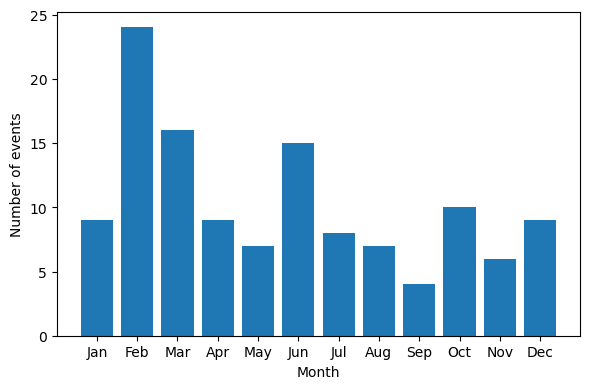

In [8]:
fig = plt.figure(figsize=[6, 4])
ax = fig.add_subplot()
process_utils.plot_event_seasonality(ds, ax=ax)
plt.show()

In [9]:
ranked_years = df.sort_values(by='pr', ascending=False)
print(ranked_years.head(n=10))

              pr  event_time
time                        
1990  309.776855  1990-02-04
1949  264.844543  1949-06-18
2015  259.481903  2015-04-22
2007  258.163055  2007-06-09
1930  251.686829  1930-06-18
1927  227.571899  1926-12-29
1946  216.690765  1946-04-17
1908  181.437012  1908-02-24
1964  175.244171  1964-06-11
1931  173.923019  1931-04-24


In [10]:
rx2day_2007 = ranked_years.iloc[3]['pr']

In [11]:
rx2day_2007

np.float64(258.1630554199219)

In [12]:
gev_shape, gev_loc, gev_scale = eva.fit_gev(ds['pr'].values)

In [15]:
print(gev_shape, gev_loc, gev_scale)

-0.16430780833624065 88.21125647918953 31.261283011766082


In [19]:
ns_shape, ns_loc0, ns_loc1, ns_scale0, ns_scale1 = eva.fit_gev(
    ds['pr'].values,
    stationary=False,
    covariate=ds['time'],
    pick_best_model=True
)

In [20]:
print(ns_shape, ns_loc0, ns_loc1, ns_scale0, ns_scale1)

<xarray.DataArray ()> Size: 8B
array(-0.19726691) <xarray.DataArray ()> Size: 8B
array(88.6642457) <xarray.DataArray ()> Size: 8B
array(0.00022527) <xarray.DataArray ()> Size: 8B
array(32.55709707) <xarray.DataArray ()> Size: 8B
array(-0.00012624)


49 year return period
95% CI: 26-186 years


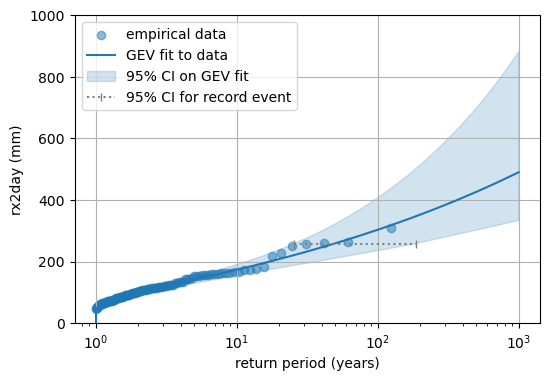

In [21]:
fig = plt.figure(figsize=[6, 4])
ax = fig.add_subplot()
eva.plot_gev_return_curve(
    ax,
    ds['pr'].values,
    rx2day_2007,
    direction="exceedance",
    bootstrap_method='parametric',
    n_bootstraps=100,
    max_return_period=3,
    ylabel='rx2day (mm)',
    ylim=(0, 1000),
)
plt.show()

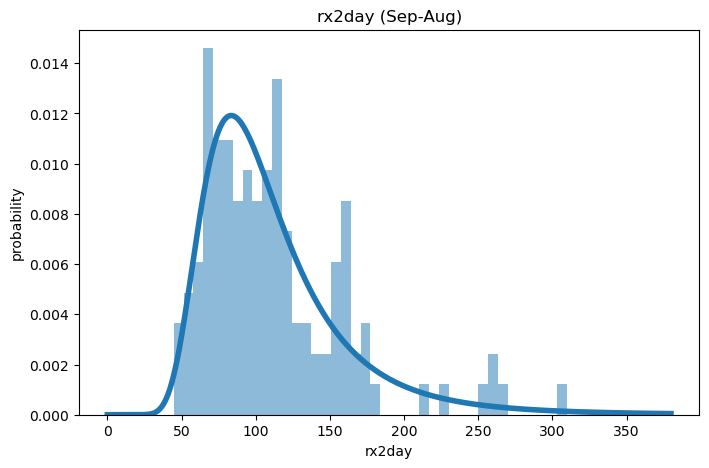

In [22]:
fig, ax = plt.subplots(figsize=[8, 5])
gev_xvals = np.arange(0, 380, 0.1)

ds['pr'].plot.hist(bins=40, density=True, color='tab:blue', alpha=0.5)
pdf = gev.pdf(gev_xvals, shape, loc, scale)
plt.plot(gev_xvals, pdf, color='tab:blue', linewidth=4.0, label='AGCD')

plt.xlabel('rx2day')
plt.ylabel('probability')
plt.title(f'rx2day (Sep-Aug)')
#plt.xlim(xmin, xmax)
plt.show()